In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import yaml
import joblib

In [4]:
shot_number = 170000
yaml_path = "../src/faith/preprocess/config/default.yaml"
with open(yaml_path, 'r') as f:
    cfg = yaml.safe_load(f)

from faith.preprocess.extract.data_extraction import (
    extract_signal, 
    extract_running_time, 
    align_signal,
)
from faith.preprocess.transform.sample_processing import (
    split_samples,
    remove_empty_samples,
    save_sample,
)
from faith.preprocess.transform.signal_processing import (
    identity_transform,
    stft_transform,
    resample_transform,
    resample_linear_transform,
)

In [5]:
start_time, end_time = extract_running_time(
    shot_number=shot_number,
    directory=Path(cfg["raw_data_dir"]),
    ip_threshold=cfg["ip_threshold"],
    start_time=cfg["start_time"],
    end_time=cfg["end_time"],
    )

In [6]:
print(start_time, ",", end_time)
# note, they are offset by 0.05ms

12.75 , 5678.5


In [8]:
cfg['signal'] = {'magnetics_high_resolution': cfg['signal']['magnetics_high_resolution']}

In [9]:
cfg['fs_khz'] = 1000

In [10]:
dfs = []
missing_signals = []
for signal in cfg['signal'].items():
    print(signal[0])
    print(signal[1])
    try:
        df = extract_signal(
            shot_number=shot_number,
            directory=Path(cfg["raw_data_dir"]),
            signal=signal[0], 
            start_time=start_time,
            end_time=end_time,
        )
        df.columns = [
            f"{signal[1]['abbr']}_{col}" if col != "time" else col
            for col in range(len(df.columns))
        ]
        df = align_signal(
            df=df,
            start_time=start_time,
            end_time=end_time,
            fs=cfg["fs_khz"],
        )
        dfs.append(df)
    except Exception as e:
        for channel in range(int(signal[1]['expected_channels'])):
            missing_signals.append((signal[1]['abbr'], channel))

magnetics_high_resolution
{'abbr': 'mhr', 'make_stft': True, 'expected_channels': 8}


In [11]:
df = pd.concat(dfs, axis=1, join='inner')
for signal_abbr, channel in missing_signals:
    df[f"{signal_abbr}_{channel}"] = np.nan
    df[f"{signal_abbr}_{channel}_state"] = False

In [16]:
import scipy.io.wavfile as wavfile

In [46]:
wav_vals = df['mhr_4'].values
wav_vals = wav_vals[~np.isnan(wav_vals)]
print(wav_vals.min(), wav_vals.max())

wav_vals = (wav_vals - wav_vals.min()) / (wav_vals.max() - wav_vals.min())
wav_vals = wav_vals - 0.5

wav_vals = np.int16(wav_vals * 32767)

sample_rate = int(22400)  # Convert kHz to Hz
wavfile.write('output.wav', sample_rate, wav_vals)
print(f"Saved WAV file with {len(wav_vals)} samples at {sample_rate} Hz")


-155.95071 133.22498
Saved WAV file with 5665749 samples at 22400 Hz


In [35]:
wav_vals = df[df['mhr_4_state'] == True]['mhr_4'].values
wav_vals_mean = wav_vals.mean()
wav_vals_std = wav_vals.std()
wav_vals = (wav_vals - wav_vals_mean) / wav_vals_std
# Remove outliers using z-score method (values beyond 3 standard deviations)
z_scores = np.abs((wav_vals - wav_vals.mean()) / wav_vals.std())
outlier_mask = z_scores < 2
wav_vals = wav_vals[outlier_mask]
print(f"Removed {np.sum(~outlier_mask)} outliers, {len(wav_vals)} samples remaining")

wav_vals = wav_vals - 0.5
wav_vals = np.int16(wav_vals * 32767)

sample_rate = int(44100)  # Convert kHz to Hz
wavfile.write('output.wav', sample_rate, wav_vals)
print(f"Saved WAV file with {len(wav_vals)} samples at {sample_rate} Hz")

Removed 109982 outliers, 1987169 samples remaining
Saved WAV file with 1987169 samples at 44100 Hz


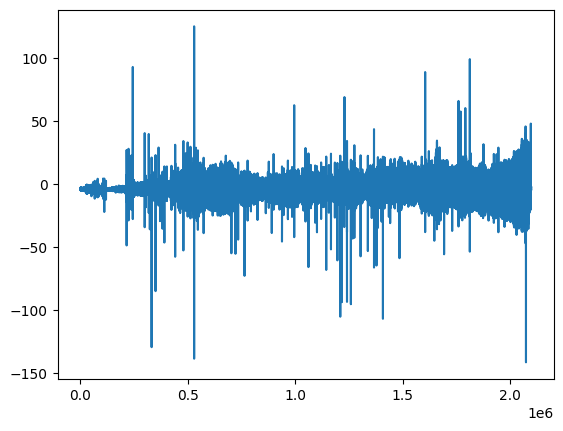

In [29]:
plt.plot(wav_vals)
plt.show()

In [12]:
# Create timedelta column
time_duration = end_time - start_time  # Duration in milliseconds
df['timedelta'] = np.linspace(start_time, end_time, len(df))
# Convert timedelta to proper timedelta format
# df['timedelta'] = pd.to_timedelta(df['timedelta'], unit='ms')

In [13]:
samples = split_samples(
    df=df,
    shot_number=shot_number,
    window_ms=cfg["window_ms"],
    hop_ms=cfg["hop_ms"],
    fs_khz=cfg["fs_khz"],
)
len(samples)

1

In [14]:
samples = remove_empty_samples(samples)
len(samples)

1

In [63]:
for sample in samples:
    transformed_samples = {}
    for key, value in sample.items():
        for signal in cfg['signal'].items():
            abbr = signal[1]['abbr']
            cols = [col for col in value.columns if abbr in col]
            transformed_samples[abbr] = identity_transform(
                x=value[cols].to_numpy().T)
            print(abbr, transformed_samples[abbr].shape)
        transformed_samples['time_ms'] = identity_transform(
            x=np.array([value['timedelta'].to_numpy().T])
        )
        save_sample(transformed_samples, Path('../data'), key)

mhr (8, 1, 3272613)
ece (48, 1, 3272613)
co2 (4, 1, 3272613)
gas (5, 1, 3272613)
ech (11, 1, 3272613)
pin (8, 1, 3272613)
tin (8, 1, 3272613)


In [15]:
first_arr = np.array([list(samples[0].values())[0].iloc[:, 0].values])
transform_shape = stft_transform(x=first_arr).shape
print(first_arr.shape, transform_shape)

(1, 5665749) (1, 513, 22132)


In [18]:
for sample in samples:
    transformed_samples = {}
    for key, value in sample.items():
        for signal in cfg['signal'].items():
            abbr = signal[1]['abbr']
            cols = [col for col in value.columns if abbr in col]
            if signal[1]['make_stft']:
                transformed_samples[abbr] = stft_transform(
                    x=value[cols].to_numpy().T,
                    n_fft=cfg["stft"]["n_fft"],
                    hop_length=cfg["stft"]["hop_length"],
                )
            else:
                transformed_samples[abbr] = resample_transform(
                    x=value[cols].to_numpy().T,
                    ref_shape=transform_shape,
                )
            print(abbr, transformed_samples[abbr].shape)
        transformed_samples['time_ms'] = resample_linear_transform(
            x=np.array([value['timedelta'].to_numpy().T]),
            ref_shape=transform_shape,
        )
        save_sample(transformed_samples, Path('../data'), key)
        break
    break

mhr (8, 513, 22132)
(1, 5665749)
(1, 513, 22132)
(5665749,)
(22132,)
(1, 5665749)


../data/170000_0.joblib
mhr (8, 513, 22132)
time_ms (1, 1, 22132)


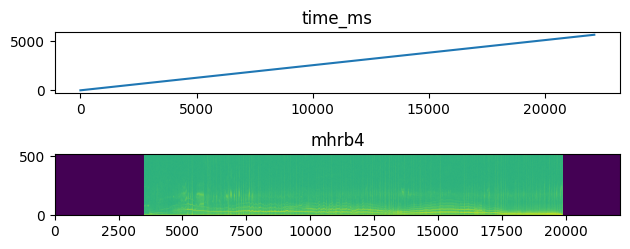

In [22]:
file_name = f'../data/{shot_number}_0.joblib'
print(file_name)
data = joblib.load(file_name)
for key, value in data.items():
    print(key, value.shape)
plt.subplot(4, 1, 1)
plt.plot(data['time_ms'][0,0,:].T)
# plt.xlim(0, len(data['time_ms'][0,0,:]))
plt.title('time_ms')
plt.subplot(4, 1, 2)
plt.imshow(np.log(data['mhr'][4] + 1e-6), aspect='auto', origin='lower')
plt.title('mhrb4')
# plt.subplot(4, 1, 3)
# plt.imshow(np.log(data['co2'][0].T + 1e-6), aspect='auto', origin='lower')
# plt.title('co2r0')
# plt.subplot(4, 1, 4)
# plt.imshow(data['pin'][:,:,0], aspect='auto', origin='lower', interpolation='none')
# plt.title('pin')
plt.tight_layout()
plt.show()

In [16]:
file_name = f'../data/{shot_number}_0.joblib'
print(file_name)
data = joblib.load(file_name)
for key, value in data.items():
    print(key, value.shape)

../data/180245_0.joblib
mhr (8, 1, 3634770)
ece (48, 1, 3634770)
co2 (4, 1, 3634770)
gas (5, 1, 3634770)
ech (11, 1, 3634770)
pin (8, 1, 3634770)
tin (8, 1, 3634770)
time_ms (1, 1, 3634770)


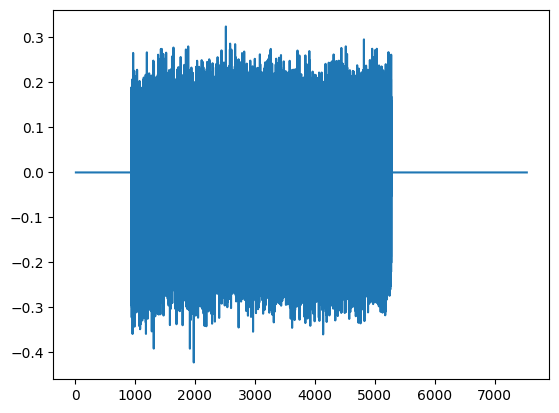

In [23]:
plt.plot(data['time_ms'][0,0,:].T, data['mhr'][0,0,:].T)
plt.show()